# 🚢 টাইটানিক ডেটাসেট: মিসিং ভ্যালু হ্যান্ডলিং (Class 01, 02, 03)

## 📌 ভূমিকা (Introduction)

এই নোটবুকে আমরা **Titanic Dataset** নিয়ে কাজ করব এবং শিখব কিভাবে **Missing Value (Null Value)** হ্যান্ডল করা হয়।

### আমাদের লক্ষ্য (Our Task):
- ডেটাসেট লোড করে এক্সপ্লোর করা
- কোন কোন কলামে Null Value আছে তা খুঁজে বের করা
- **Mean, Median, Mode Imputation** ব্যবহার করে Null Value পূরণ করা
- **Random Sample Imputation** ব্যবহার করে Null Value পূরণ করা
- KDE Plot এর মাধ্যমে কোন মেথড সবচেয়ে ভালো কাজ করে তা ভিজুয়ালাইজ করে compare করা

### কেন এটা গুরুত্বপূর্ণ?
Real-world ডেটাসেটে প্রায়ই Missing Value থাকে। মডেল ট্রেইন করার আগে এই Null Value গুলো হ্যান্ডল করতে হয়, না হলে মডেল error দেবে বা ভুল prediction করবে। সঠিক ইম্পিউটেশন মেথড বেছে নেওয়াটা একটি গুরুত্বপূর্ণ স্কিল।

---

In [308]:
# প্রয়োজনীয় লাইব্রেরি ইম্পোর্ট করা হচ্ছে
# pandas -> ডেটা লোড ও ম্যানিপুলেশনের জন্য
# matplotlib.pyplot -> গ্রাফ/প্লট আঁকার জন্য

import pandas as pd
import matplotlib.pyplot as plt

## 📂 ডেটাসেট লোড করা (Loading Dataset)

`pd.read_csv()` ফাংশন দিয়ে আমরা CSV ফাইল থেকে ডেটা লোড করি এবং একটি **DataFrame** তৈরি করি।

> ⚠️ **সাধারণ ভুল (Common Mistake):** ফাইল পাথ ভুল দিলে `FileNotFoundError` আসবে। Colab এ কাজ করার সময় ফাইলটি প্রথমে আপলোড করে নিতে হবে।

In [309]:
# CSV ফাইল থেকে ডেটাসেট লোড করা হচ্ছে
dataset=pd.read_csv('titanic.csv')

## 👀 ডেটাসেট দেখা (Viewing the Dataset)

পুরো ডেটাসেটটি প্রিন্ট করে দেখা হচ্ছে — এতে সব row ও column দেখা যাবে (যদিও বড় ডেটাসেটে pandas মাঝখানের অংশ truncate করে দেখায়)।

In [310]:
# সম্পূর্ণ ডেটাসেট দেখানো হচ্ছে
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 🔝 প্রথম কয়েকটি রো দেখা — `head()`

`head(n)` ফাংশন দিয়ে ডেটাসেটের **শুরুর n সংখ্যক row** দেখা যায়। ডিফল্টভাবে `n=5`।

| ফাংশন | কাজ |
|---|---|
| `head()` | প্রথম ৫টি row |
| `head(10)` | প্রথম ১০টি row |
| `tail(10)` | শেষ ১০টি row |

> 💡 **টিপস:** বড় ডেটাসেটে কাজ শুরু করার আগে `head()` দিয়ে দেখা ভালো practice — এতে কলাম গুলোর structure বোঝা যায়।

In [311]:
dataset.head()   # Prothom theke 5 ta data show korbe

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [312]:
dataset.head(10)   # Prothom theke 10 ta data show korbe

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [313]:
dataset.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


## 🏷️ কলামের নাম দেখা — `columns`

`dataset.columns` ব্যবহার করে আমরা ডেটাসেটের সকল **ফিচার/কলামের নাম** জানতে পারি। এটা জানা জরুরি কারণ পরে কোন কলাম নিয়ে কাজ করব তা ঠিক করতে হবে।

In [314]:
# feature gular naam janar jonne
dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## 📊 স্ট্যাটিস্টিক্যাল সামারি — `describe()`

`describe()` ফাংশন শুধুমাত্র **numerical column** গুলোর জন্য Statistical Summary দেখায়:

- **count**: কতগুলো non-null value আছে
- **mean**: গড় মান
- **std**: Standard Deviation
- **min/max**: সর্বনিম্ন/সর্বোচ্চ মান
- **25%, 50%, 75%**: Quartile values

$$\text{Mean} (\mu) = \frac{\sum_{i=1}^{n} x_i}{n}$$

> ⚠️ **ভুল ধারণা:** এটি categorical (text) column এর জন্য কাজ করে না, শুধু numerical column এর জন্য কাজ করে।

In [315]:
# sob numerical column er jonnr min, max, count etc...shob ashbe (numerical result gular jonne dekhabe)
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## ❓ Null Value চেক করা — `isnull()`

`isnull()` ফাংশন প্রতিটি cell চেক করে **True/False** রিটার্ন করে — `True` মানে সেই cell **খালি (NaN/Null)**।

In [316]:
# dataset er vitore kono null value ase kina check dibe
# true mane faka ase
dataset.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


## 🔢 প্রতিটি কলামে কতগুলো Null Value — `isnull().sum()`

`isnull().sum()` দিয়ে প্রতিটি কলামে **কতগুলো Null Value** আছে তার সংখ্যা পাওয়া যায়।

> উদাহরণ: যদি `Age = 177` দেখায়, তার মানে Age কলামে ১৭৭টি ফাঁকা (Missing) ভ্যালু আছে।

এই তথ্য জানা গুরুত্বপূর্ণ কারণ এর ভিত্তিতেই আমরা decide করব কোন Imputation মেথড ব্যবহার করব।

In [317]:
# age=177 mane 177 ta faka value ase
dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 🎯 নির্দিষ্ট কলাম নিয়ে নতুন DataFrame তৈরি — `usecols`

এখন আমরা পুরো ডেটাসেট থেকে শুধু `Age`, `Cabin`, `Embarked` — এই ৩টি কলাম নিয়ে একটি নতুন DataFrame `df` তৈরি করছি, কারণ এই ৩টি কলামেই Missing Value আছে এবং আমরা এগুলো নিয়ে কাজ করব।

`usecols` parameter দিয়ে নির্দিষ্ট কলাম সিলেক্ট করা যায়, ফলে মেমোরি কম খরচ হয়।

In [318]:
# abar dataset read korbo karon amake oi 3 ta column niye kaj korte hobe
# etake ekhn df naam dibo
df=pd.read_csv('titanic.csv', usecols=["Age","Cabin","Embarked"])

In [319]:
df

,Age,Cabin,Embarked
0,22.0,NaN,S
1,38.0,C85,C
2,26.0,NaN,S
3,35.0,C123,S
4,35.0,NaN,S
...,...,...,...
886,27.0,NaN,S
887,19.0,B42,S
888,NaN,NaN,S
889,26.0,C148,C


# 1️⃣ মেথড ১: Mean Imputation (গড় দিয়ে পূরণ)

## 🧠 থিওরি (Theory)

**Mean Imputation** হলো একটি Numerical Column এর Missing Value-কে সেই কলামের **গড় (Mean)** মান দিয়ে পূরণ করার পদ্ধতি।

$$\text{Mean} (\mu) = \frac{\sum_{i=1}^{n} x_i}{n}$$

### কেন ব্যবহার করি?
- সহজ ও দ্রুত পদ্ধতি
- Data এর সাইজ ছোট হয় না (কোনো row বাদ যায় না)

### সমস্যা / ভুল ব্যবহার (Drawbacks):
- যদি Data-তে **Outlier** থাকে, Mean সেটার দ্বারা প্রভাবিত হবে এবং ভুল মান দিয়ে পূরণ করবে
- Original Distribution এর **Variance কমিয়ে দেয়**
- শুধুমাত্র Numerical Data এর জন্য প্রযোজ্য

**Mean diye replace** ✅

In [320]:
mean= df["Age"].mean()
mean

np.float64(29.69911764705882)

## ⚙️ Reusable Function তৈরি করা

এখানে আমরা একটি **Function** বানাচ্ছি যা যেকোনো DataFrame, Column এবং Replace value নিয়ে নতুন কলাম তৈরি করে Null Value রিপ্লেস করবে।

### Function এর কাজ:
1. মূল কলামের নামের সাথে `mean`/`mode`/`median` জুড়ে দিয়ে **নতুন কলাম** তৈরি করা
2. `fillna()` ফাংশন দিয়ে Null Value-গুলো নির্দিষ্ট মান দিয়ে পূরণ করা

> 💡 **নোট:** `diu` parameter দিয়ে DataFrame পাস করা হচ্ছে — কারণ Function এর ভেতরে সরাসরি `df` নামটি চেনা যায় না, তাই parameter এর মাধ্যমে পাঠাতে হয়।

> ⚠️ **সাধারণ ভুল:** `fillna()` ব্যবহার করার পর `inplace=True` না দিলে এবং নতুন কলামে assign না করলে পরিবর্তন সংরক্ষিত হয় না।

In [321]:
# Creating a Function
# diu= parameter ...eikhetre jehetu ei function ta dataset ke chine na sehetu dataset er variable diu
# Age ke pass korar jonne variable namr parameter use kortesi
# ei function er kaj Age_mean toiri kore oikhan er null value ke mean diye replace kora

def input_nan(diu, variable, mean):
  diu[variable+"_mean"]=diu[variable].fillna(mean)

## 🚀 Function কল করা (Function Call)

এখন আমরা আমাদের তৈরি করা `input_nan` ফাংশনটিকে কল করছি, যেখানে:
- `df` = আমাদের DataFrame
- `"Age"` = যে কলামে কাজ করব
- `mean` = যে মান দিয়ে Null পূরণ হবে

In [322]:
# function call
input_nan(df,"Age",mean)

In [323]:
df

,Age,Cabin,Embarked,Age_mean
0,22.0,NaN,S,22.000000
1,38.0,C85,C,38.000000
2,26.0,NaN,S,26.000000
3,35.0,C123,S,35.000000
4,35.0,NaN,S,35.000000
...,...,...,...,...
886,27.0,NaN,S,27.000000
887,19.0,B42,S,19.000000
888,NaN,NaN,S,29.699118
889,26.0,C148,C,26.000000


## ✅ যাচাই করা — Null Value আছে কিনা

`isnull().sum()` দিয়ে আবার চেক করছি — মূল `Age` কলামে এখনো Null থাকবে, কিন্তু নতুন `Age_mean` কলামে Null থাকবে **0**, কারণ সব Null Value Mean দিয়ে পূরণ হয়ে গেছে।

In [324]:
df.isnull().sum()

,0
Age,177
Cabin,687
Embarked,2
Age_mean,0


# 2️⃣ মেথড ২: Mode Imputation (সর্বাধিক বার আসা মান দিয়ে পূরণ)

## 🧠 থিওরি (Theory)

**Mode** হলো একটি কলামে **সর্বাধিকবার repeat হওয়া মান (Most Frequent Value)**।

### কেন ব্যবহার করি?
- **Categorical Data** এর জন্য সবচেয়ে বেশি ব্যবহৃত পদ্ধতি (যেমন: Embarked column)
- Numerical Data তেও ব্যবহার করা যায়, যখন data discrete হয়

### সমস্যা / ভুল ব্যবহার:
- Mode বারবার ব্যবহার করলে একটি নির্দিষ্ট মানের **frequency অস্বাভাবিকভাবে বেড়ে যায়**
- Distribution এর shape পরিবর্তন হয়ে যেতে পারে

> ⚠️ **সাধারণ ভুল:** `df["Age"].mode()` রিটার্ন করে একটি **Series** (কারণ একাধিক mode থাকতে পারে), তাই `[0]` ব্যবহার করে প্রথম mode value নিতে হয়। `[0]` না দিলে index সহ পুরো Series চলে আসবে এবং `fillna()` ঠিকমতো কাজ করবে না।

**Mode diye replace** ✅

In [325]:
# Mode diye replace so mode er man ber korbo
# [0] disi karon eita na dile index soho ashbe. mode diye replace hobe  na
mode=df["Age"].mode()[0]
mode

np.float64(24.0)

## ⚙️ Mode-এর জন্য Function

আগের মতো একই কাঠামোর Function, কিন্তু এবার `mean` parameter এর জায়গায় `mode` মান পাস করা হবে, যা নতুন `Age_mode` কলাম তৈরি করবে।

In [326]:
def input_nan(diu, variable, mode):
  diu[variable+"_mode"]=diu[variable].fillna(mode)

In [327]:
# function call
input_nan(df, "Age", mode)

In [328]:
df

,Age,Cabin,Embarked,Age_mean,Age_mode
0,22.0,NaN,S,22.000000,22.0
1,38.0,C85,C,38.000000,38.0
2,26.0,NaN,S,26.000000,26.0
3,35.0,C123,S,35.000000,35.0
4,35.0,NaN,S,35.000000,35.0
...,...,...,...,...,...
886,27.0,NaN,S,27.000000,27.0
887,19.0,B42,S,19.000000,19.0
888,NaN,NaN,S,29.699118,24.0
889,26.0,C148,C,26.000000,26.0


In [329]:
df.isnull().sum()

,0
Age,177
Cabin,687
Embarked,2
Age_mean,0
Age_mode,0


# 3️⃣ মেথড ৩: Median Imputation (মধ্যক মান দিয়ে পূরণ)

## 🧠 থিওরি (Theory)

**Median** হলো ডেটাকে ছোট থেকে বড় ক্রমে সাজানোর পর **মাঝখানের মান**।

$$\text{Median} = \begin{cases} x_{\frac{n+1}{2}} & \text{if } n \text{ is odd} \\ \frac{x_{n/2} + x_{(n/2)+1}}{2} & \text{if } n \text{ is even} \end{cases}$$

### কেন ব্যবহার করি?
- **Mean** এর তুলনায় Median **Outlier দ্বারা কম প্রভাবিত** হয়
- Skewed distribution এর জন্য বেশি reliable

### সমস্যা / ভুল ব্যবহার:
- তারপরেও এটি Original Variance/Distribution পরিবর্তন করে ফেলে
- Distribution-এর shape একদম accurate রাখে না

> ⚠️ **কোডে সাধারণ ভুল (Bug Alert):** নিচের কোডে function এর parameter নাম `moedian` (টাইপো) লেখা হয়েছে কিন্তু function body-তে বাইরের গ্লোবাল ভ্যারিয়েবল `median` ব্যবহার হচ্ছে। যদিও এটি কাজ করে (কারণ Python গ্লোবাল ভ্যারিয়েবল খুঁজে নেয়), এটি **ভালো প্র্যাকটিস না**। সঠিকভাবে লিখলে parameter নামটাই function body-তে ব্যবহার করা উচিত।

**Median diye replace** ✅

In [330]:
median=df["Age"].median()
median

28.0

In [331]:
def input_nan(diu, variable, mode):
  diu[variable+"_median"]=diu[variable].fillna(median)

In [332]:
# function call
input_nan(df, "Age", median)
df

,Age,Cabin,Embarked,Age_mean,Age_mode,Age_median
0,22.0,NaN,S,22.000000,22.0,22.0
1,38.0,C85,C,38.000000,38.0,38.0
2,26.0,NaN,S,26.000000,26.0,26.0
3,35.0,C123,S,35.000000,35.0,35.0
4,35.0,NaN,S,35.000000,35.0,35.0
...,...,...,...,...,...,...
886,27.0,NaN,S,27.000000,27.0,27.0
887,19.0,B42,S,19.000000,19.0,19.0
888,NaN,NaN,S,29.699118,24.0,28.0
889,26.0,C148,C,26.000000,26.0,26.0


In [333]:
df.isnull().sum()

,0
Age,177
Cabin,687
Embarked,2
Age_mean,0
Age_mode,0
Age_median,0


## 📈 Age এবং Age_mean প্লট

এখন পর্যন্ত আমরা যে যে কলাম তৈরি করেছি (`Agemean`, `Agemode`, `Agemedian`), পরের অংশে এদের **Distribution (KDE Plot)** আঁকব এবং original `Age` এর সাথে তুলনা করব — দেখব কোন মেথড সবচেয়ে কম distortion করছে।

---

# 📘 Class 02 শুরু

## 📊 সাধারণ Line Plot — `Age` কলাম

`df["Age"].plot()` ব্যবহার করলে ডিফল্টভাবে একটি **Line Plot** তৈরি হয়, যেখানে x-axis এ index এবং y-axis এ Age value দেখানো হয়।

> 💡 এটা মূলত EDA (Exploratory Data Analysis)-এর প্রাথমিক ধাপ — ডেটার একটা rough visual ধারণা পাওয়া।

<Axes: >

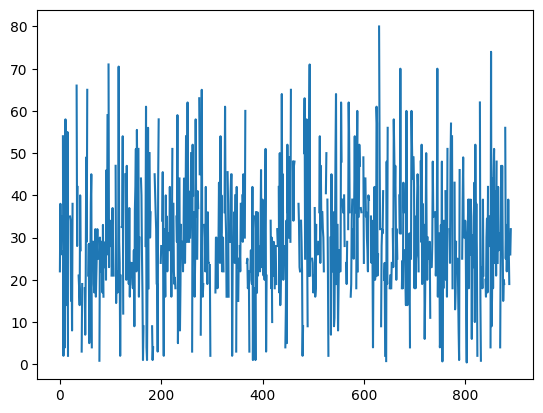

In [334]:
df["Age"].plot()

## 📉 KDE Plot — Distribution তুলনা (Age vs Agemean)

**KDE (Kernel Density Estimation)** Plot একটি কন্টিনিউয়াস কলামের **Probability Density (সম্ভাব্যতা ঘনত্ব)** দেখায় — এটা Histogram এর smooth ভার্সন বলা যায়।

`kind="kde"` parameter দিয়ে KDE Plot আঁকা হয়।

এখানে Original `Age` এবং `Agemean` এর Distribution একসাথে প্লট করে দেখা হচ্ছে — তুলনা করার জন্য যে Mean Imputation কতটা Original Distribution পরিবর্তন করল।

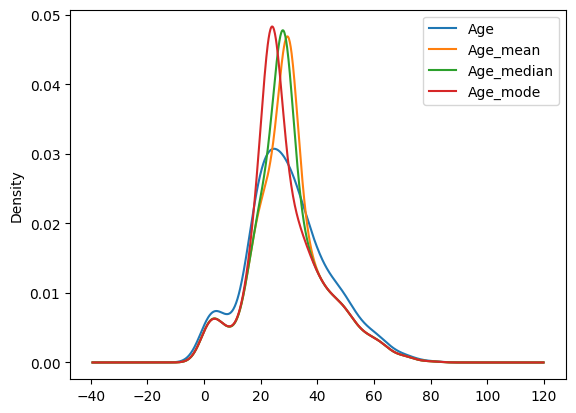

In [335]:
df["Age"].plot(kind="kde")
# kind: Literal['line', 'bar', 'barh', 'hist', 'box', 'kde', 'density', 'area', 'pie', 'scatter', 'hexbin']
df["Age_mean"].plot(kind="kde")
df["Age_median"].plot(kind="kde")
df["Age_mode"].plot(kind="kde",)
#df['Age'].plot(kind='kde')

plt.legend(['Age','Age_mean','Age_median','Age_mode'])

## 🎨 প্লটকে আরও আকর্ষণীয় ও স্পষ্ট করা (Enhanced KDE Plot)

আগের প্লটটি ছিল একদম বেসিক। এখন আমরা কিছু এক্সট্রা উপাদান যুক্ত করব যাতে গ্রাফটি **প্রফেশনাল ও পরিষ্কার** দেখায়:

| উপাদান | কাজ |
|---|---|
| `figsize` | প্লটের সাইজ বড় ও readable করে |
| `title()` | গ্রাফের উদ্দেশ্য বোঝায় |
| `xlabel`, `ylabel` | অক্ষগুলো কী বোঝাচ্ছে তা স্পষ্ট করে |
| `linewidth`, `linestyle` | লাইনগুলো আলাদাভাবে চেনা সহজ করে |
| `color` | প্রতিটি কার্ভকে আলাদা রঙ দেয় |
| `grid()` | ব্যাকগ্রাউন্ডে গ্রিড লাইন দেখায়, value পড়া সহজ হয় |
| `legend(loc=...)` | লেজেন্ডের পজিশন ঠিক করে, গ্রাফের উপর overlap এড়ায় |
| `tight_layout()` | সব এলিমেন্ট সুন্দরভাবে ফিট হয় |

> ⚠️ **সাধারণ ভুল:** অনেকে `plt.show()` ভুলে যায় বা `legend()` এ ভুল ক্রমে নাম দেয় (যে ক্রমে `plot()` কল হয়েছে, ঠিক সেই ক্রমে লেজেন্ডের নাম দিতে হবে)।

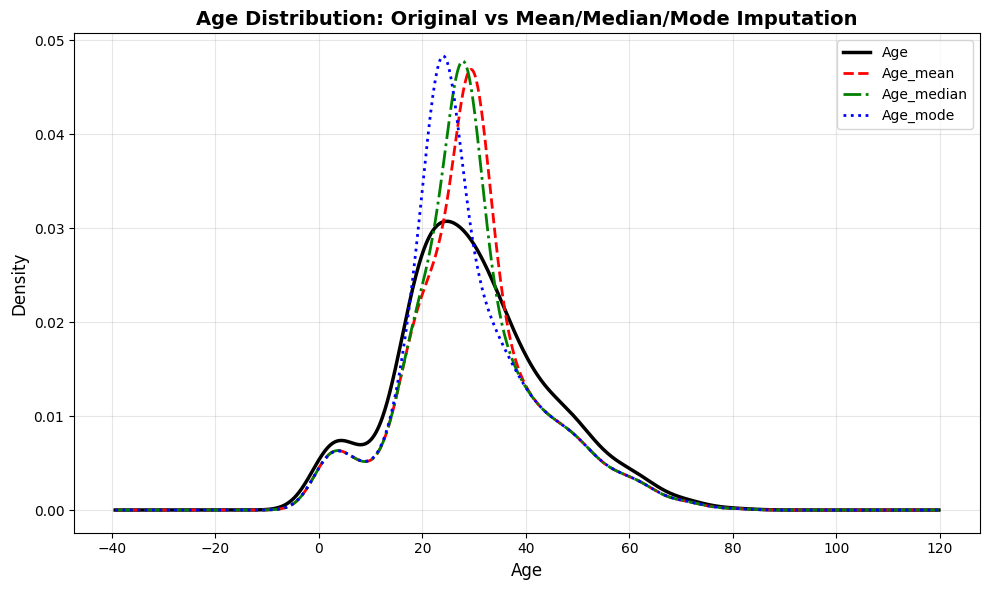

In [336]:
# প্লটের সাইজ বড় করা হচ্ছে (width=10, height=6) যাতে স্পষ্ট দেখা যায়
plt.figure(figsize=(10,6))

# প্রতিটি কলামের জন্য আলাদা রঙ ও লাইন স্টাইল দেওয়া হচ্ছে
df["Age"].plot(kind="kde", color="black", linewidth=2.5, linestyle="-")
df["Age_mean"].plot(kind="kde", color="red", linewidth=2, linestyle="--")
df["Age_median"].plot(kind="kde", color="green", linewidth=2, linestyle="-.")
df["Age_mode"].plot(kind="kde", color="blue", linewidth=2, linestyle=":")

# গ্রাফের টাইটেল ও অক্ষের নাম যুক্ত করা হচ্ছে
plt.title("Age Distribution: Original vs Mean/Median/Mode Imputation", fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Density", fontsize=12)

# ব্যাকগ্রাউন্ডে গ্রিড লাইন যুক্ত করা হচ্ছে (হালকা স্বচ্ছ)
plt.grid(True, alpha=0.3)

# legend এর পজিশন নির্দিষ্ট করা হচ্ছে যাতে গ্রাফের সাথে overlap না করে
plt.legend(['Age','Age_mean','Age_median','Age_mode'], loc="upper right", fontsize=10)

# সব এলিমেন্ট সুন্দরভাবে ফিট করানো হচ্ছে
plt.tight_layout()

# প্লট দেখানো হচ্ছে
plt.show()

# 4️⃣ মেথড ৪: Random Sample Imputation

## 🧠 থিওরি (Theory)

Mean, Mode, Median — কোনোটিই সম্পূর্ণরূপে **Efficient (কার্যকর)** না, কারণ এগুলো একই মান বারবার ব্যবহার করে Distribution-কে বিকৃত করে।

এর সমাধান হলো **Random Sample Imputation** — Missing Value-গুলোকে সেই কলামের **non-null মানগুলো থেকে এলোমেলোভাবে (randomly) sample করে** পূরণ করা হয়। এতে Original Distribution অনেকটাই বজায় থাকে।

### সুবিধা:
- Original Distribution/Variance ভালোভাবে বজায় থাকে
- KDE Plot-এ Original এর সাথে almost মিলে যায়

### সমস্যা:
- প্রতিবার Random হওয়ায় ফলাফল ভিন্ন হতে পারে — তাই **`random_state`** ব্যবহার করা জরুরি, যাতে Reproducibility (একই রিজাল্ট সবসময় পাওয়া) বজায় থাকে

**Mean, Mode, Median keo efficient na. tai amra use korbo Sampling.** ✅

In [337]:
df["Age"].sample()


,Age
283,19.0


## 🎲 কতগুলো Sample প্রয়োজন?

যেহেতু `Age` কলামে যতগুলো Null Value আছে, ঠিক **তত সংখ্যক Sample** নিতে হবে — যাতে প্রতিটি Null Value-কে একটি Sample দিয়ে replace করা যায়।

`df["Age"].sample(n)` → `n` সংখ্যক random value রিটার্ন করে।

In [338]:
df["Age"].sample(df["Age"].isnull().sum())

,Age
594,37.0
561,40.0
678,43.0
536,45.0
450,36.0
...,...
673,31.0
160,44.0
330,NaN
713,29.0


## 🔒 Random State এবং `dropna()`

- `dropna()` → Null Value বাদ দিয়ে বাকি সব মান নিয়ে আসে (যাতে Null থেকে Sample না নেওয়া হয়)
- `random_state=0` → একটি **Seed Value**, যা নিশ্চিত করে যে প্রতিবার একই Random Sample আসবে (Reproducibility)

> 💡 **মনে রাখো:** `random_state` না দিলে প্রতিবার রান করলে ভিন্ন ভিন্ন Sample আসবে, এবং রেজাল্ট compare করা কঠিন হয়ে যাবে।

In [345]:
# Null value chara 177 ta value dibe
# Random State use korechi jate sobar PC te same  177 ta null chara value ney
df["Age"].dropna().sample(df["Age"].isnull().sum(),random_state=0)

,Age
423,28.00
177,50.00
305,0.92
292,36.00
889,26.00
...,...
539,22.00
267,25.00
352,15.00
99,34.00


## ⚙️ Random Sample Imputation Function

এই Function-টি একটু complex। এর কাজ ধাপে ধাপে:

1. মূল কলামের একটি কপি নতুন `_sample` কলামে তৈরি করা
2. Non-null values থেকে Null Value সংখ্যক Random Sample নেওয়া (`random_state=0` দিয়ে)
3. **Index Matching:** Random sample-এর index গুলো, মূল কলামের যেসব জায়গায় Null আছে, সেই index-গুলোর সাথে match করানো (`random_sample.index = ...`)
4. `df.loc[]` ব্যবহার করে শুধুমাত্র Null থাকা position-গুলোতে Random Sample-এর মান বসানো

> ⚠️ **সবচেয়ে গুরুত্বপূর্ণ ও কমন ভুল:** যদি Index Matching (`random_sample.index = df[df[variable].isnull()].index`) এই লাইনটি না থাকে, তাহলে Pandas সঠিক position-এ মান বসাতে পারবে না (কারণ index mismatch হবে) এবং পুরো কলাম `NaN` দিয়ে ভরে যাবে।

> 💡 `df.loc[condition, column]` — এটি একটি শক্তিশালী Conditional Assignment পদ্ধতি, যা শুধুমাত্র শর্ত পূরণ করা row-গুলোতে মান বসায়।

In [346]:
def input_sample(df,variable):
  df[variable+"_sample"]=df[variable]
  random_sample=df[variable].dropna().sample(df[variable].isnull().sum(),random_state=0)
  random_sample.index=df[df[variable].isnull()].index
  df.loc[df[variable].isnull(),variable+"_sample"]=random_sample



## 🚀 Function কল করা

এখন `input_sample` ফাংশনটি কল করে `df`-তে `Age_sample` নামে নতুন কলাম তৈরি হবে, যেখানে Null Value গুলো Random Sample দিয়ে পূরণ হয়ে গেছে।

In [347]:
input_sample(df,"Age")
df

,Age,Cabin,Embarked,Age_mean,Age_mode,Age_median,Age_sample
0,22.0,NaN,S,22.000000,22.0,22.0,22.0
1,38.0,C85,C,38.000000,38.0,38.0,38.0
2,26.0,NaN,S,26.000000,26.0,26.0,26.0
3,35.0,C123,S,35.000000,35.0,35.0,35.0
4,35.0,NaN,S,35.000000,35.0,35.0,35.0
...,...,...,...,...,...,...,...
886,27.0,NaN,S,27.000000,27.0,27.0,27.0
887,19.0,B42,S,19.000000,19.0,19.0,19.0
888,NaN,NaN,S,29.699118,24.0,28.0,15.0
889,26.0,C148,C,26.000000,26.0,26.0,26.0


## 📉 ফাইনাল তুলনা — KDE Plot (Age vs Age_sample)

Original `Age` এবং `Age_sample` কলামের KDE Plot পাশাপাশি দেখানো হচ্ছে। লক্ষ্য করো — দুটি Curve প্রায় **একই rকম দেখাচ্ছে**, যা প্রমাণ করে Random Sample Imputation Original Distribution কে সবচেয়ে ভালোভাবে রক্ষা করে।

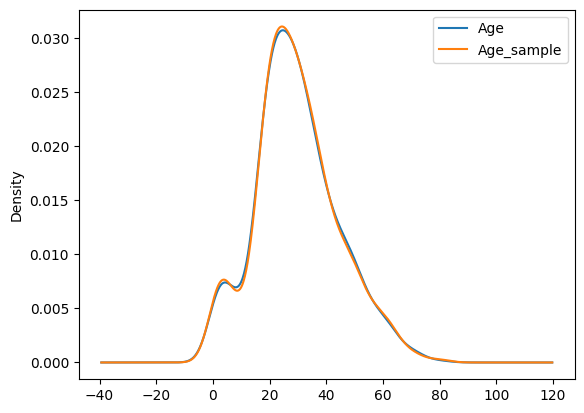

In [348]:
df["Age"].plot(kind="kde")
df["Age_sample"].plot(kind="kde")
plt.legend(['Age','Age_sample'])

## 🎨 Age vs Age_sample — উন্নত KDE প্লট

এই প্লটে Original `Age` এবং `Age_sample` (Random Sample Imputation) এর Distribution তুলনা করা হচ্ছে। আগের মতোই `figsize`, `title`, `xlabel/ylabel`, `grid`, এবং আলাদা `color`/`linestyle` যুক্ত করে গ্রাফকে স্পষ্ট ও প্রফেশনাল করা হলো।

> 💡 লক্ষ্য করো — দুটি কার্ভ প্রায় একই রকম, যা প্রমাণ করে Random Sample Imputation Original Distribution সবচেয়ে ভালোভাবে বজায় রাখে।

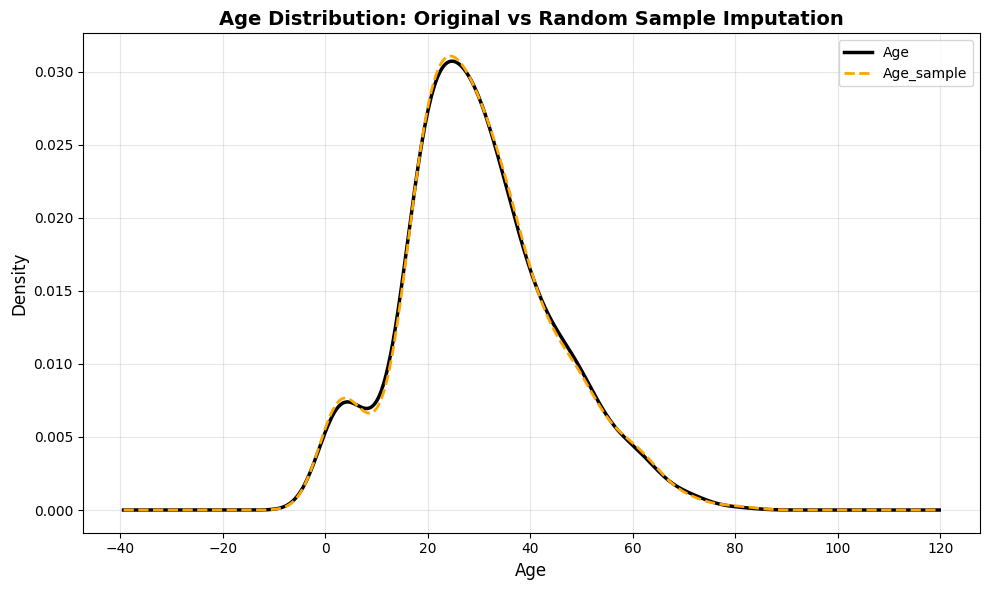

In [349]:
# প্লটের সাইজ বড় করা হচ্ছে যাতে স্পষ্ট দেখা যায়
plt.figure(figsize=(10,6))

# Original Age এবং Age_sample এর KDE plot, আলাদা রঙ ও লাইন স্টাইলে
df["Age"].plot(kind="kde", color="black", linewidth=2.5, linestyle="-")
df["Age_sample"].plot(kind="kde", color="orange", linewidth=2, linestyle="--")

# টাইটেল ও অক্ষের নাম যুক্ত করা হচ্ছে
plt.title("Age Distribution: Original vs Random Sample Imputation", fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Density", fontsize=12)

# হালকা গ্রিড লাইন যুক্ত করা হচ্ছে
plt.grid(True, alpha=0.3)

# legend এর পজিশন নির্ধারণ করা হচ্ছে
plt.legend(['Age','Age_sample'], loc="upper right", fontsize=10)

# সব এলিমেন্ট সুন্দরভাবে ফিট করানো হচ্ছে
plt.tight_layout()

# প্লট দেখানো হচ্ছে
plt.show()

## ✅ ফলাফল (Conclusion)

**Er mane sampling diye replace kora better** — Random Sample Imputation, Mean/Mode/Median এর তুলনায় Original Distribution সবচেয়ে ভালোভাবে বজায় রাখে।

---

# 🏁 চূড়ান্ত সারসংক্ষেপ (Final Summary)

## 📋 চারটি Imputation মেথডের তুলনা

| মেথড | কী দিয়ে পূরণ হয় | Distribution-এর উপর প্রভাব | কখন ব্যবহার করবে |
|---|---|---|---|
| **Mean** | কলামের গড় মান | Variance কমে যায়, Outlier-এ sensitive | সাধারণ Normal Distribution, কম Outlier |
| **Mode** | সবচেয়ে frequent মান | একটি মানের frequency বেড়ে যায় | Categorical Data |
| **Median** | মধ্যক মান | Mean এর চেয়ে ভালো, কিন্তু shape পরিবর্তন হয় | Skewed Distribution, Outlier থাকলে |
| **Random Sample** | Random non-null মান | Original Distribution সবচেয়ে ভালো বজায় থাকে | যখন Distribution Shape সংরক্ষণ জরুরি |

## 🔑 মূল শিক্ষা (Key Takeaway)

> Missing Value হ্যান্ডলিং করার সময় শুধু "কোনো একটা মান দিয়ে পূরণ করলাম" ভাবলেই হবে না — **Original Data এর Distribution/Pattern যতটা সম্ভব বজায় রাখাটাই** সবচেয়ে গুরুত্বপূর্ণ। তাই বেশিরভাগ ক্ষেত্রে **Random Sample Imputation** সবচেয়ে ভালো ফলাফল দেয়, যদিও Mean/Median/Mode সহজ এবং দ্রুত পদ্ধতি।

⭐ যদি এই নোটবুকটি ভালো লাগে, GitHub-এ Star দিতে ভুলো না!